In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

Data Collection and Processing

In [2]:
# loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv('/content/car data.csv')

In [3]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
car_dataset.shape

(301, 9)

In [5]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
# checking the number of missing values
car_dataset.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [12]:
# checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


Encoding the Categorical Data

In [13]:
# Encoding "Fuel Type" Column
car_dataset.replace({'Fuel_Type': {'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)

# Encoding "Seller Type" Column
car_dataset.replace({'Seller_Type': {'Dealer':0,'Individual':1}}, inplace=True)

# Encoding "Transmission" Column
car_dataset.replace({'Transmission': {'Manual':0,'Automatic':1}}, inplace=True)

/tmp/ipykernel_873/2214060232.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type': {'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)
/tmp/ipykernel_873/2214060232.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type': {'Dealer':0,'Individual':1}}, inplace=True)
/tmp/ipykernel_873/2214060232.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy

In [14]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


Splitting the data and target

In [15]:
X = car_dataset.drop(columns=['Car_Name','Selling_Price'], axis=1)
Y = car_dataset['Selling_Price']

In [16]:
print(X)

     Year  Present_Price  Kms_Driven  ...  Seller_Type  Transmission  Owner
0    2014           5.59       27000  ...            0             0      0
1    2013           9.54       43000  ...            0             0      0
2    2017           9.85        6900  ...            0             0      0
3    2011           4.15        5200  ...            0             0      0
4    2014           6.87       42450  ...            0             0      0
..    ...            ...         ...  ...          ...           ...    ...
296  2016          11.60       33988  ...            0             0      0
297  2015           5.90       60000  ...            0             0      0
298  2009          11.00       87934  ...            0             0      0
299  2017          12.50        9000  ...            0             0      0
300  2016           5.90        5464  ...            0             0      0

[301 rows x 7 columns]


In [17]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


Splitting Training and Test Data

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=2)

Model Training => Linear and Lasso Regression

1. Linear Regression

In [19]:
lin_reg_model = LinearRegression()

In [20]:
lin_reg_model.fit(X_train, Y_train)

LinearRegression()

Model Evaluation

In [24]:
# Prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [25]:
# For regression we use various metrics such as R squared, Mean absolute error, Root mean squared error, etc

# R Squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ",error_score)

# Note: for accuracy score we can tell that if accuracy score of our model i more than 75%, then our model is
# performing well. But we can not say the same in the case of R squared error.
# we use ACCURACY SCORE for classification problem and regression case we use R SQUARED ERROR.

R squared Error :  0.8799451660493711


Visualize the actual prices and predicted prices

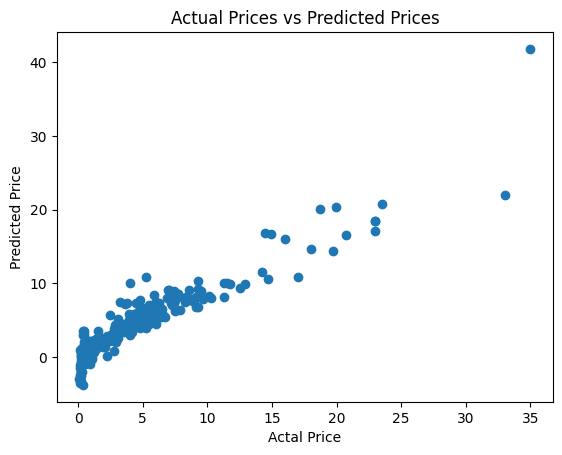

In [26]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actal Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [27]:
# prediction on Test Data
test_data_prediction = lin_reg_model.predict(X_test)

In [29]:
# R squared error
error_score_test = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ",error_score_test)

R squared error :  0.8365766715027051


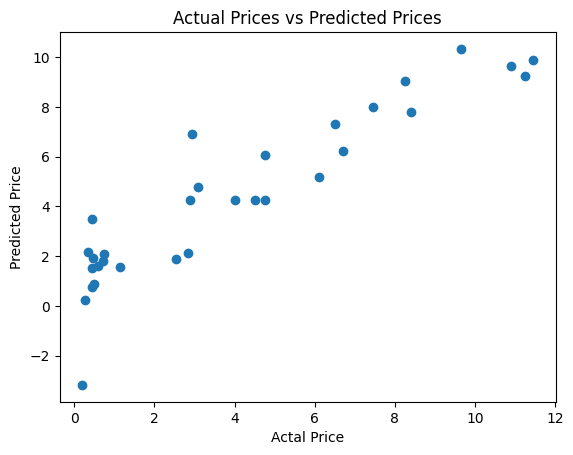

In [30]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actal Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

2. Lasso Regression

In [31]:
lass_reg_model = Lasso()

In [32]:
lass_reg_model.fit(X_train, Y_train)

Lasso()

Model evaluation

In [33]:
training_data_prediction = lass_reg_model.predict(X_train)

In [34]:
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared error : ",error_score)

R squared error :  0.8427856123435794


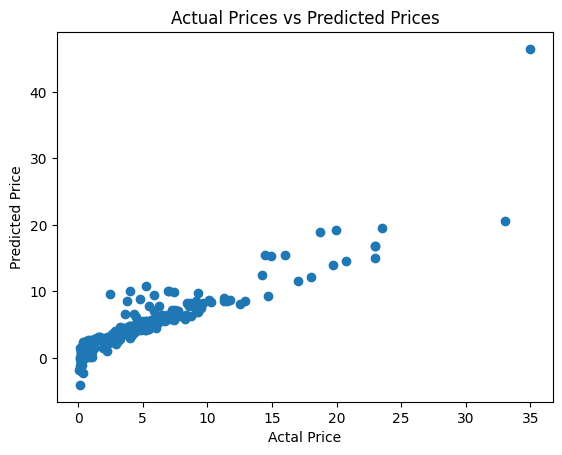

In [35]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actal Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [36]:
test_data_prediction = lass_reg_model.predict(X_test)

In [37]:
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ",error_score)

R squared error :  0.8709167941173195


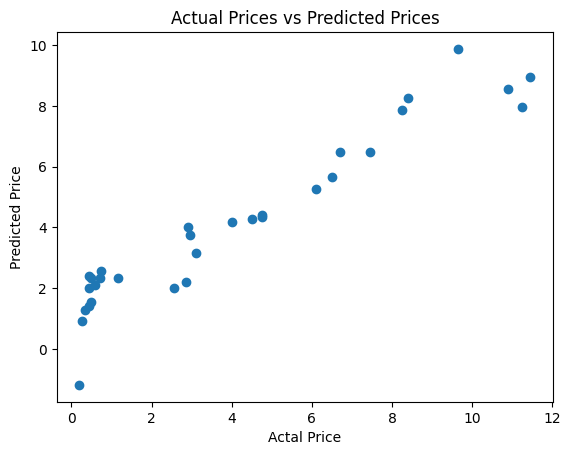

In [40]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actal Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

Building a Predictive System

In [49]:
print(X_test.iloc[1])

Year              2014.000
Present_Price        0.826
Kms_Driven       23000.000
Fuel_Type            0.000
Seller_Type          1.000
Transmission         0.000
Owner                0.000
Name: 161, dtype: float64


In [62]:
input = (X_test.iloc[5].values)
type(input)

input_data_as_numpy_array = np.asarray(input)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction_from_linear = lin_reg_model.predict(input_data_reshaped)
print(prediction_from_linear)

prediction_from_lasso = lass_reg_model.predict(input_data_reshaped)
print(prediction_from_lasso)

print(Y_test.iloc[5])


[4.24823193]
[4.29397384]
4.5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
